# LightNav-0：让 MicroDuck 听懂指令，在不同房间中导航

这本 Notebook［交互式教程］对应 21 天学习计划的 Task 8。使用已有模型，不训练、不连接开发板。
LightNav-0 在 GPU［图形处理器］上读取第一视角图像与语言指令，预测局部轨迹；
MPC［模型预测控制］将轨迹转为速度命令，已有行走策略控制小鸭子的 14 个关节，MuJoCo 完成接触与物理仿真。

将依次运行官方多房间住宅、自建客厅和自建走廊。每个场景分别生成视频、预测记录和轨迹图。
为便于课堂复现，推理期间暂停仿真，视频按仿真时间播放；延迟表记录真实推理耗时。
低层行走沿用官方 ONNX Runtime［模型推理运行时］的 CPU［中央处理器］接口。


## 1. 环境与默认路径

在 Ubuntu 上使用模拟器环境作为内核。首次准备环境的方法见
[配套代码说明](../02-可运行代码/lightnav-learning/README.md)。
默认值对应本专题工作站已有资源；在另一台机器上修改下方路径或对应环境变量即可。
模型权重与视频保存在仓库外，重复运行覆盖同一场景的最新结果。

In [1]:
import os
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "4")
import json
from pathlib import Path
import subprocess
import shutil
import sys
import numpy as np
from IPython.display import display, Image, Video, Markdown
get_ipython().run_line_magic("matplotlib", "inline")

def locate_topic():
    configured = os.getenv("MICRODUCK_TOPIC_ROOT")
    if configured:
        return Path(configured).expanduser().resolve()
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "02-可运行代码" / "lightnav-learning").is_dir():
            return base
    raise FileNotFoundError("请从本专题的 03-Notebook 目录启动内核，或设置 MICRODUCK_TOPIC_ROOT。")

TOPIC = locate_topic()
LIGHTNAV_ROOT = Path(os.getenv("LIGHTNAV_ROOT", str(Path.home() / "projects/LightNav-0")))
MODEL_ENV = Path(os.getenv("LIGHTNAV_MODEL_ENV", "/data/Data14TB/envs/lightnav-0"))
MODEL_PATH = Path(os.getenv("LIGHTNAV_MODEL_PATH", "/data/Data14TB/checkpoints/LightNav-0"))
ROBOT_MODEL = Path(os.getenv("LIGHTNAV_ROBOT_MODEL", str(Path.home() / "workspaces/microduck_rl/src/mjlab_microduck/robot/microduck/robot_allcollisions.xml")))
WALKING_POLICY = Path(os.getenv("LIGHTNAV_WALKING_POLICY", "/data/Data14TB/checkpoints/microduck-navigation/alpha_walking.onnx"))
OUTPUT = Path(os.getenv("LIGHTNAV_OUTPUT", "/data/Data14TB/lightnav-recordings/teaching/notebook"))
OUTPUT.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DIR = TOPIC / "03-Notebook"
WEB_OUTPUT = NOTEBOOK_DIR / "outputs/lightnav_gpu"
WEB_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
if WEB_OUTPUT.is_symlink():
    assert WEB_OUTPUT.resolve() == OUTPUT.resolve(), "已有输出链接指向不同位置，请先核对。"
    WEB_OUTPUT.unlink()
WEB_OUTPUT.mkdir(exist_ok=True)
for resource in (LIGHTNAV_ROOT / "mujoco_demo/vln_mujoco", MODEL_ENV / "bin/lightnav-serve", MODEL_PATH / "eval_config.json", ROBOT_MODEL, WALKING_POLICY):
    assert resource.exists(), f"缺少资源：{resource}"
sys.path.insert(0, str(LIGHTNAV_ROOT / "mujoco_demo"))
sys.path.insert(0, str(TOPIC / "02-可运行代码/lightnav-learning"))
from lightnav_lesson import ensure_model_server, build_scenes, make_robot, camera_image, decode_response, run_episode
print("资源检查通过；输出目录：", OUTPUT)
print("本次使用已有模型；训练关闭；无需开发板。")

资源检查通过；输出目录： /data/Data14TB/lightnav-recordings/teaching/notebook
本次使用已有模型；训练关闭；无需开发板。


## 2. 确认计算环境

导航模型与模拟器使用独立环境。这里只检查可用性和软件版本，不输出具体硬件型号。

In [2]:
import importlib.metadata as metadata
import mujoco
import onnxruntime
gpu_check = subprocess.run(
    [str(MODEL_ENV / "bin/python"), "-c", "import torch,vllm,json; print(json.dumps({'cuda_available':torch.cuda.is_available(),'vllm':vllm.__version__}))"],
    capture_output=True, text=True, check=True,
)
compute = json.loads(gpu_check.stdout.strip().splitlines()[-1])
assert compute["cuda_available"], "导航模型需要可用的 GPU。"
assert compute["vllm"] == "0.19.1", "请使用上游固定版本的模型环境。"
print(compute)
print({name: metadata.version(name) for name in ("mujoco", "onnxruntime", "nbclient")})
print("学习流程：图像与语言 → 局部轨迹 → 速度命令 → 关节动作 → 新图像。")

{'cuda_available': True, 'vllm': '0.19.1'}
{'mujoco': '3.12.0', 'onnxruntime': '1.29.0', 'nbclient': '0.11.0'}
学习流程：图像与语言 → 局部轨迹 → 速度命令 → 关节动作 → 新图像。


## 3. 启动导航模型

vLLM［语言模型推理引擎］加载官方预训练权重。已有服务会直接复用；首次启动等模型预热完成后再继续。
后端不可用时直接报错，不使用手工路径代替模型预测。

In [3]:
MODEL_PORT = int(os.getenv("LIGHTNAV_MODEL_PORT", "8050"))
service = ensure_model_server(MODEL_ENV, MODEL_PATH, OUTPUT, port=MODEL_PORT)
SERVER_URL = service["url"]
print(service)
config = json.loads((MODEL_PATH / "eval_config.json").read_text())
print("动作表示：10 个平面位姿；每个位姿包含前进距离、横向距离与偏航角。")
print("动作解码器已随权重提供：", (MODEL_PATH / "action_tokenizer").is_dir())

{'url': 'ws://127.0.0.1:8050', 'state': 'existing listener'}
动作表示：10 个平面位姿；每个位姿包含前进距离、横向距离与偏航角。
动作解码器已随权重提供： True


## 4. 官方场景与两个新布局

官方住宅保持原样。新客厅与走廊重新布置墙体、地面和家具，复用官方场景中的真实网格资源。
客厅观察目标物体接近；走廊观察窄空间与侧面家具对路径的影响。
目标位置仅用于事后测量距离，不传给导航模型，也不用于生成控制命令。

In [4]:
scenes = build_scenes(OUTPUT / "scenes")
for name, scene in scenes.items():
    print(name, "|", scene["instruction"])
print("场景与修改记录：", OUTPUT / "scenes/manifest.json")

official_apartment | Walk to the table on your left and stop.
living_room | Walk to the armchair in front of you and stop.
corridor | Go straight down the hallway to the potted plant and stop.
场景与修改记录： /data/Data14TB/lightnav-recordings/teaching/notebook/scenes/manifest.json


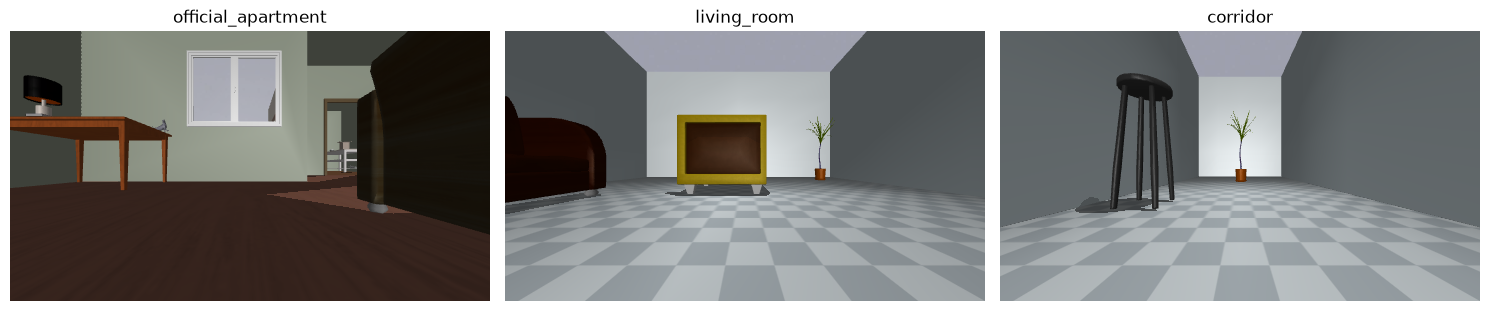

三个场景均已完成模型编译、第一视角渲染与 61 维观测检查。


In [5]:
import matplotlib.pyplot as plt
robots = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (name, scene) in zip(axes, scenes.items()):
    robot = make_robot(scene, ROBOT_MODEL, WALKING_POLICY)
    robots[name] = robot
    assert robot.model.nu == 14
    assert robot.policy.observation().shape == (61,)
    with mujoco.Renderer(robot.model, height=270, width=480) as renderer:
        axis.imshow(camera_image(robot, renderer))
    axis.set_title(name)
    axis.axis("off")
plt.tight_layout()
plt.show()
print("三个场景均已完成模型编译、第一视角渲染与 61 维观测检查。")

## 5. 读懂一次真实预测

图像与指令通过 WebSocket［双向通信协议］发送到模型。
两个空间指向通道用于表达目标和下一行动位置，RVQ［残差向量量化］动作码被解码为 10×3 的平面轨迹。
下方直接显示模型返回的文本、停止标志与前几个轨迹点。

In [6]:
import base64
import io
import websocket
from contextlib import closing
from PIL import Image as PILImage
robot = robots["living_room"]
with mujoco.Renderer(robot.model, height=270, width=480) as renderer:
    rgb = camera_image(robot, renderer)
buffer = io.BytesIO()
PILImage.fromarray(rgb).save(buffer, format="JPEG")
with closing(websocket.create_connection(SERVER_URL, timeout=90, http_no_proxy=["127.0.0.1", "localhost"])) as connection:
    connection.send(json.dumps({"action": "login", "data": {"clientId": "notebook-first-prediction"}}))
    assert json.loads(connection.recv())["data"]["rc"] == 0
    connection.send(json.dumps({"action": "next", "data": {"seq": 1, "image": base64.b64encode(buffer.getvalue()).decode(), "instruction": scenes["living_room"]["instruction"]}}))
    first_prediction, waypoints = decode_response(connection.recv(), 1)
print("模型文本：", first_prediction.get("raw_text", ""))
print("停止标志：", first_prediction["stop"], "；轨迹形状：", waypoints.shape)
print("前 3 个轨迹点：\n", np.round(waypoints[:3], 3))

模型文本： <apos_839><opos_455><act_l0_16><act_l1_0><act_l2_208><|im_end|>
停止标志： False ；轨迹形状： (10, 3)
前 3 个轨迹点：
 [[0.146 0.039 0.262]
 [0.291 0.078 0.262]
 [0.437 0.117 0.262]]


## 6. 三个场景分别运行并生成视频

每段视频左侧是模型读取的第一视角，右侧是第三视角。按仿真时间运行，推理时仿真暂停。
控制器跟踪模型预测轨迹，行走策略在 50 Hz［每秒 50 次］控制关节。
停止由模型输出触发；跌倒会结束该次实验。执行记录保留真实结果，不自动挑选成功片段。

In [7]:
EPISODE_SECONDS = float(os.getenv("LIGHTNAV_EPISODE_SECONDS", "24"))
reports = {}
def demonstrate(name):
    report, images = run_episode(name, scenes[name], ROBOT_MODEL, WALKING_POLICY, SERVER_URL, OUTPUT, seconds=EPISODE_SECONDS)
    reports[name] = report
    print(f"场景：{name}；停止原因：{report['termination']}；真实预测次数：{report['prediction_count']}")
    print(f"仿真时长：{report['sim_seconds']:.2f} s；推理延迟中位数：{report['median_latency_ms']:.1f} ms")
    print(f"目标中心距离：{report['initial_target_distance_m']:.2f} → {report['final_target_distance_m']:.2f} m")
    print(f"完整报告：{name}_report.json；导航模型运行在 GPU［图形处理器］。")
    shutil.copy2(report["video"], WEB_OUTPUT / f"{name}_latest.mp4")
    display(Video(f"outputs/lightnav_gpu/{name}_latest.mp4", embed=False, width=720,
                  html_attributes='controls style="max-width:100%;height:auto;"'))
    preview = OUTPUT / f"{name}_start_end.png"
    PILImage.fromarray(np.concatenate(images, axis=0)).save(preview)
    display(Image(filename=str(preview), width=720))
    return report
print("参数：", {"simulation_seconds": EPISODE_SECONDS, "prediction_hz": 4, "video_fps": 10})

参数： {'simulation_seconds': 24.0, 'prediction_hz': 4, 'video_fps': 10}


### 官方住宅


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



场景：official_apartment；停止原因：model_stop；真实预测次数：32
仿真时长：8.75 s；推理延迟中位数：100.7 ms
目标中心距离：2.95 → 2.10 m
完整报告：official_apartment_report.json；导航模型运行在 GPU［图形处理器］。


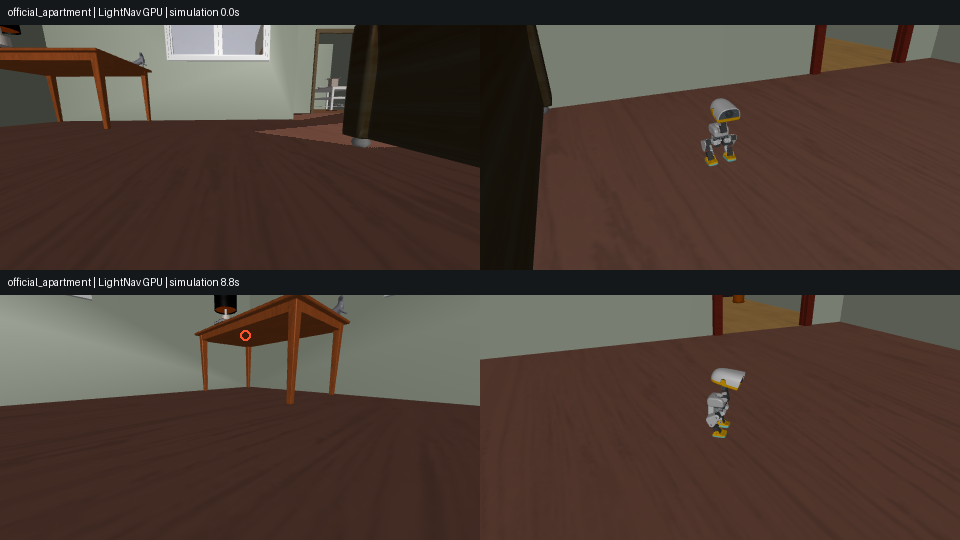

In [8]:
official_report = demonstrate("official_apartment")

### 自建客厅

场景：living_room；停止原因：model_stop；真实预测次数：12
仿真时长：3.75 s；推理延迟中位数：92.3 ms
目标中心距离：1.81 → 1.47 m
完整报告：living_room_report.json；导航模型运行在 GPU［图形处理器］。


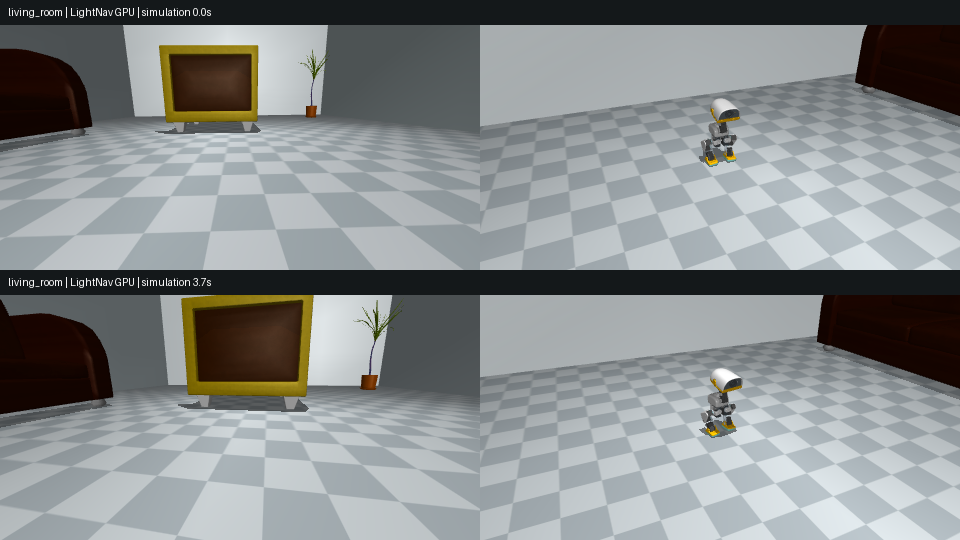

In [9]:
living_report = demonstrate("living_room")

### 自建走廊

场景：corridor；停止原因：model_stop；真实预测次数：49
仿真时长：13.00 s；推理延迟中位数：110.9 ms
目标中心距离：2.70 → 1.19 m
完整报告：corridor_report.json；导航模型运行在 GPU［图形处理器］。


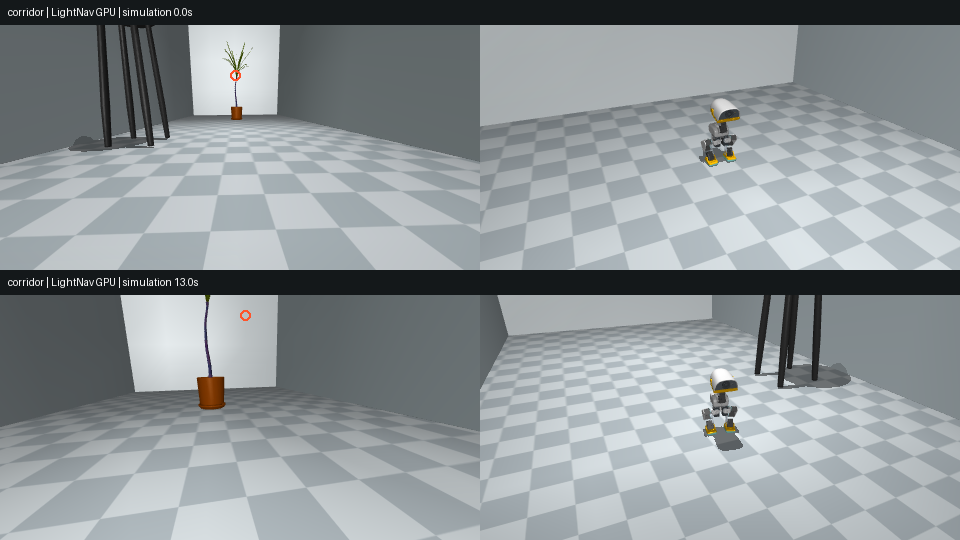

In [10]:
corridor_report = demonstrate("corridor")

## 7. 对照真实轨迹与推理耗时

蓝线为机器人实际走过的路径，红点为测量用的目标位置。
`model_stop` 表示模型发出停止，`time_limit` 表示达到实验时长，`fall` 表示跌倒；
结合末端距离和视频观察任务完成情况，停止标志本身不等于到达目标。

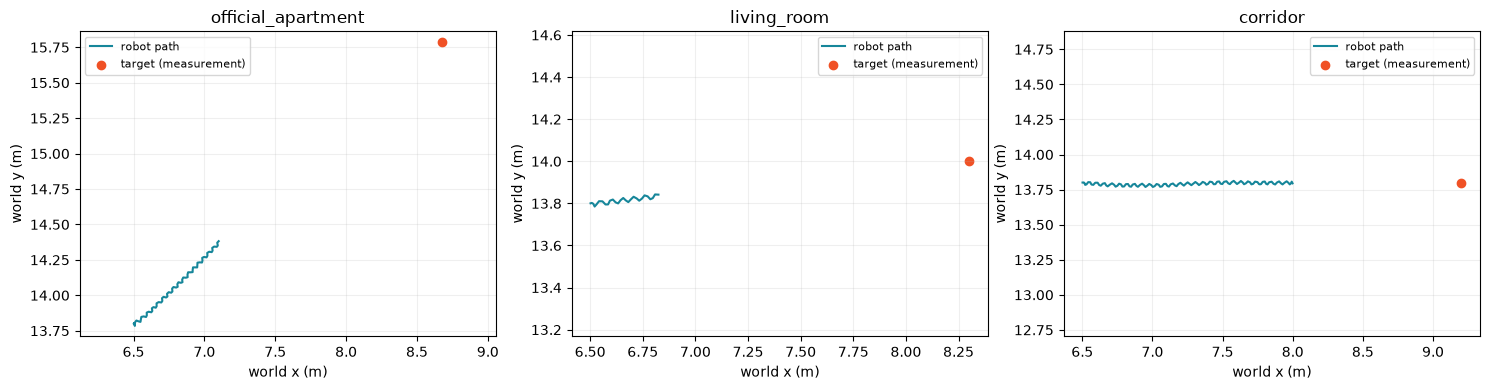

official_apartment: model_stop, predictions=32, distance=2.95 → 2.10 m, median=100.7 ms
living_room: model_stop, predictions=12, distance=1.81 → 1.47 m, median=92.3 ms
corridor: model_stop, predictions=49, distance=2.70 → 1.19 m, median=110.9 ms


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (name, scene) in zip(axes, scenes.items()):
    trace = json.loads((OUTPUT / f"{name}_trace.json").read_text())
    axis.plot([p["x"] for p in trace], [p["y"] for p in trace], color="#16869a", label="robot path")
    axis.scatter(*scene["target_xy"], color="#f05125", label="target (measurement)")
    axis.set(title=name, xlabel="world x (m)", ylabel="world y (m)")
    axis.set_aspect("equal", adjustable="datalim")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()
for name, report in reports.items():
    print(f"{name}: {report['termination']}, predictions={report['prediction_count']}, distance={report['initial_target_distance_m']:.2f} → {report['final_target_distance_m']:.2f} m, median={report['median_latency_ms']:.1f} ms")

## 8. 检查与继续探索

下一轮可以修改语言描述、家具位置或起始朝向，并分别比较视频、轨迹和模型指向。
改动场景后重新运行场景构建与后续实验单元。模型、行走策略与物理参数先保持一致，便于判断变化来自哪里。

[LightNav-0 官方代码](https://github.com/lightorigins/LightNav-0) ·
[官方模拟器说明](https://github.com/lightorigins/LightNav-0/blob/main/mujoco_demo/README.md) ·
[模型权重](https://huggingface.co/LightOriginsHQ/LightNav-0)

In [12]:
import imageio.v2 as imageio
assert set(reports) == set(scenes)
for name, report in reports.items():
    assert report["prediction_count"] > 0
    assert report["trajectory_shape"] == [10, 3]
    assert not report["training"]
    assert (OUTPUT / f"{name}_latest.mp4").stat().st_size > 1000
    with imageio.get_reader(WEB_OUTPUT / f"{name}_latest.mp4") as video:
        assert video.get_meta_data()["duration"] > 0
        assert video.get_data(0).std() > 2, "视频首帧为空白。"
    predictions = json.loads((OUTPUT / f"{name}_predictions.json").read_text())
    assert len(predictions) == report["prediction_count"]
summary = OUTPUT / "lesson_summary.json"
summary.write_text(json.dumps(reports, indent=2, ensure_ascii=False), encoding="utf-8")
print("完成：三个场景均记录了真实模型预测、物理仿真视频、路径与耗时。")
print("实验汇总：", summary)

完成：三个场景均记录了真实模型预测、物理仿真视频、路径与耗时。
实验汇总： /data/Data14TB/lightnav-recordings/teaching/notebook/lesson_summary.json
